# 1️⃣ 데이터 점검

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

# 0. 원본 로드
df = pd.read_csv('upworthy-archive-exploratory-packages-03.12.2020.csv')
print(f"원본: {df.shape[0]}행 {df.shape[1]}열")

# 1. 분석에 안 쓰는 컬럼 제거
cols_to_drop = ['Unnamed: 0', 'excerpt', 'lede', 'slug', 'eyecatcher_id',
                'share_text', 'square', 'created_at', 'updated_at']
df = df.drop(columns=cols_to_drop)

# 2. 완전 중복 행 제거
before = len(df)
df = df.drop_duplicates()
print(f"중복 제거: {before}행 -> {len(df)}행 (제거 {before - len(df)}행)")

# 3. 논리 모순 확인 (클릭 수가 노출 수보다 많은 경우)
bad_logic = df[df['clicks'] > df['impressions']]
print(f"clicks > impressions 모순 행: {len(bad_logic)}건")
df = df[df['clicks'] <= df['impressions']]

# 4. 배정/판정 일관성 체크: 한 실험에 winner=True가 2개 이상인 경우
winner_counts = df.groupby('clickability_test_id')['winner'].sum()
inconsistent_tests = winner_counts[winner_counts > 1].index.tolist()
print(f"판정 불일치 실험: {inconsistent_tests}")

before = len(df)
df = df[~df['clickability_test_id'].isin(inconsistent_tests)]
print(f"판정 불일치 실험 제거: {before}행 -> {len(df)}행")

# 5. 극소표본 제거 (impressions < 30)
before = len(df)
df = df[df['impressions'] >= 30]
print(f"극소표본 제거: {before}행 -> {len(df)}행")

print(f"\n최종 정제 결과: {df.shape[0]}행, 고유 실험 수 {df['clickability_test_id'].nunique()}개")

df.to_csv('upworthy_cleaned.csv', index=False)

원본: 22666행 17열
중복 제거: 22666행 -> 22665행 (제거 1행)
clicks > impressions 모순 행: 0건
판정 불일치 실험: ['547278e0ce85339079000038']
판정 불일치 실험 제거: 22665행 -> 22661행
극소표본 제거: 22661행 -> 22654행

최종 정제 결과: 22654행, 고유 실험 수 4871개


In [ ]:
test_id = '5149d406c7a0fc0002006599'
example = df[df['clickability_test_id'] == test_id]

n_a, n_b = example['impressions'].values
total = n_a + n_b

chi2, p_srm = stats.chisquare([n_a, n_b], [total/2]*2)
print(f"n_a={n_a}, n_b={n_b}")
print(f"SRM 카이제곱: chi2={chi2:.4f}, p={p_srm:.4f}")

n_a=10751, n_b=10692
SRM 카이제곱: chi2=0.1623, p=0.6870


# 2️⃣ 질문과 가설 정하기

In [ ]:
# 질문: "같은 기사에 대해, 헤드라인 문구를 다르게 하면 방문자의 클릭률(CTR)이 달라지는가?"
# H0: 두 헤드라인 버전 간 클릭률에는 차이가 없다. (모비율이 같다)
# H1: 두 헤드라인 버전 간 클릭률에는 차이가 있다. (모비율이 다르다)
# 유의수준 및 검증방향: 𝛼=0.05, 양측검정

# 3️⃣ 검정 고르기

In [ ]:
# 검정 방법 고르기: 각 방문자는 "클릭했다/안 했다"의 이분형 결과고, 우리가 보는 건 clicks/impressions라는 비율(전환율)
# 비교할 집단은 2개(헤드라인 A vs B)
# 연속형이 아니라 비율이라 정규성/등분산을 보지 않아도 된다
# 최종결론: 비율 · 2집단 = 카이제곱 독립성 검정 (또는 두 비율 검정)

# 4️⃣ 검정 수행하고 3종 세트로 보고

In [ ]:
test_id = '5149d406c7a0fc0002006599'
example = df[df['clickability_test_id'] == test_id].reset_index(drop=True)

# 2x2 분할표 만들기: 행=헤드라인, 열=[클릭O, 클릭X]
click = example['clicks'].values
no_click = example['impressions'].values - click

contingency_table = np.array([click, no_click]).T
print("분할표 (행: 헤드라인 A/B, 열: 클릭/비클릭)")
print(contingency_table)

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nchi2 = {chi2:.4f}, p = {p:.4f}, 자유도 = {dof}")
print(f"기대빈도:\n{expected}")

분할표 (행: 헤드라인 A/B, 열: 클릭/비클릭)
[[  185 10566]
 [  116 10576]]

chi2 = 15.2037, p = 0.0001, 자유도 = 1
기대빈도:
[[  150.91409784 10600.08590216]
 [  150.08590216 10541.91409784]]


In [ ]:
# 헤드라인 A와 B의 클릭률은 통계적으로 유의하게 다르다.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

# 헤드라인 A, B 각각의 클릭수/표본수
click_a, n_a = 185, 10751
click_b, n_b = 116, 10692

ctr_a = click_a / n_a
ctr_b = click_b / n_b

# ① 점추정 (두 CTR의 차이)
diff = ctr_a - ctr_b
print(f"CTR_A = {ctr_a:.4%}, CTR_B = {ctr_b:.4%}")
print(f"① 점추정 (절대 차이) = {diff:.4%}")

# ② 95% 신뢰구간 (두 비율 차이에 대한 CI)
ci_low, ci_high = confint_proportions_2indep(
    count1=click_a, nobs1=n_a,
    count2=click_b, nobs2=n_b,
    method='wald'
)
print(f"② 95% CI = [{ci_low:.4%}, {ci_high:.4%}]")

# ③ 효과크기: 절대차이(%p) + 상대차이(배수) + Cramér's V
relative_diff = (ctr_a - ctr_b) / ctr_b
n_total = n_a + n_b
cramers_v = np.sqrt(15.2037 / n_total)  # 위에서 나온 chi2 값 사용
print(f"③ 절대차이 = {diff*100:.2f}%p")
print(f"   상대차이 = {relative_diff:.1%} (A가 B보다 상대적으로 {relative_diff:.1%} 높음)")
print(f"   Cramér's V = {cramers_v:.4f}")

CTR_A = 1.7208%, CTR_B = 1.0849%
① 점추정 (절대 차이) = 0.6358%
② 95% CI = [0.3212%, 0.9505%]
③ 절대차이 = 0.64%p
   상대차이 = 58.6% (A가 B보다 상대적으로 58.6% 높음)
   Cramér's V = 0.0266


# 5️⃣ 한 걸음 더 (A, C 선택)

In [ ]:
# A. 검정력/MDE-"우리 표본으로 잡을 수 있는 가장 작은 효과는?"
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

n_a, n_b = 10751, 10692
ctr_b = 116/10692   # 대조군(B) CTR을 기준으로 삼음

analysis = NormalIndPower()

# 80% 검정력으로 잡을 수 있는 최소 효과크기(Cohen's h) 계산
mde_h = analysis.solve_power(
    effect_size=None,
    nobs1=n_a,
    alpha=0.05,
    power=0.8,
    ratio=n_b/n_a,
    alternative='two-sided'
)

# Cohen's h를 다시 %p 차이로 환산
p2 = ctr_b
p1 = (np.sin(np.arcsin(np.sqrt(p2)) + mde_h/2))**2
mde_pct_point = p1 - p2

print(f"Cohen's h (MDE) = {mde_h:.4f}")
print(f"이 표본으로 80% 검정력으로 잡을 수 있는 최소 차이(MDE) = {mde_pct_point*100:.3f}%p")
print(f"참고: 우리가 실제로 관측한 차이 = {(185/10751 - 116/10692)*100:.3f}%p")

Cohen's h (MDE) = 0.0383
이 표본으로 80% 검정력으로 잡을 수 있는 최소 차이(MDE) = 0.432%p
참고: 우리가 실제로 관측한 차이 = 0.636%p


In [ ]:
# C. 다중검정 보정 — "4,871개 실험을 다 돌리면 몇 개가 우연히 유의할까?" 
from statsmodels.stats.multitest import multipletests

# 헤드라인 2개짜리 실험만 대상으로 (우리 메인 분석이랑 같은 조건으로 비교하려고)
pkg_counts = df.groupby('clickability_test_id').size()
two_headline_tests = pkg_counts[pkg_counts == 2].index

pvalues = []
test_ids = []

for tid, g in df[df['clickability_test_id'].isin(two_headline_tests)].groupby('clickability_test_id'):
    clicks = g['clicks'].values
    no_clicks = g['impressions'].values - clicks
    table = np.array([clicks, no_clicks]).T
    chi2, p, dof, expected = stats.chi2_contingency(table)
    pvalues.append(p)
    test_ids.append(tid)

pvalues = np.array(pvalues)

# 보정 전
n_sig_before = (pvalues < 0.05).sum()
print(f"검정한 실험 수: {len(pvalues)}개")
print(f"보정 전 p<0.05 (유의하다고 나온 실험): {n_sig_before}개 ({n_sig_before/len(pvalues):.1%})")

# Bonferroni, BH(FDR) 보정
reject_bonf, pvals_bonf, _, _ = multipletests(pvalues, alpha=0.05, method='bonferroni')
reject_bh, pvals_bh, _, _ = multipletests(pvalues, alpha=0.05, method='fdr_bh')

print(f"Bonferroni 보정 후 유의: {reject_bonf.sum()}개 ({reject_bonf.sum()/len(pvalues):.1%})")
print(f"BH(FDR) 보정 후 유의: {reject_bh.sum()}개 ({reject_bh.sum()/len(pvalues):.1%})")

검정한 실험 수: 127개
보정 전 p<0.05 (유의하다고 나온 실험): 27개 (21.3%)
Bonferroni 보정 후 유의: 5개 (3.9%)
BH(FDR) 보정 후 유의: 11개 (8.7%)


In [7]:
# Bonferroni 보정 후 메인 실험 유의성 확인 코드
alpha = 0.05
n_tests = 127          # 헤드라인 2개짜리 실험 전체 개수
main_p = 0.0001        # 우리 메인 실험의 카이제곱 검정 p값

bonf_threshold = alpha / n_tests

print(f"Bonferroni 기준 임계값: {bonf_threshold:.6f}")
print(f"우리 메인 실험 p값: {main_p}")
print(f"살아남음 (여전히 유의함): {main_p < bonf_threshold}")

Bonferroni 기준 임계값: 0.000394
우리 메인 실험 p값: 0.0001
살아남음 (여전히 유의함): True


# 💡그래프 그려보기

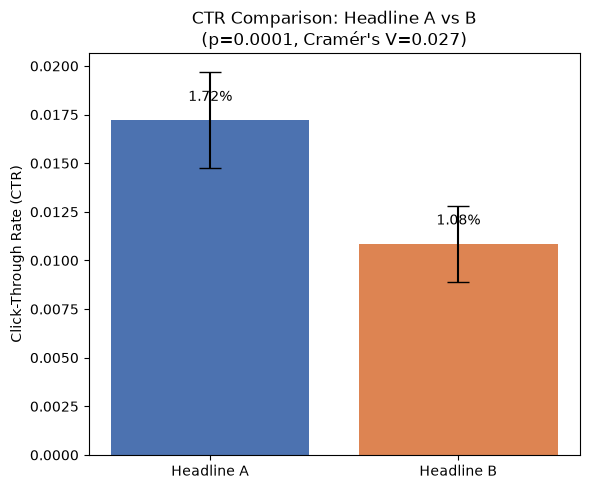

In [ ]:
# 메인 실험: CTR 막대그래프 + 신뢰구간
import matplotlib.pyplot as plt

labels = ['Headline A', 'Headline B']
ctrs = [185/10751, 116/10692]
n = [10751, 10692]

# 각 그룹 CTR의 95% CI (단일 비율 CI, 시각화용)
ci_errors = [1.96 * np.sqrt(p*(1-p)/ni) for p, ni in zip(ctrs, n)]

fig, ax = plt.subplots(figsize=(6,5))
bars = ax.bar(labels, ctrs, yerr=ci_errors, capsize=8, color=['#4C72B0','#DD8452'])
ax.set_ylabel('Click-Through Rate (CTR)')
ax.set_title('CTR Comparison: Headline A vs B\n(p=0.0001, Cramér\'s V=0.027)')

for bar, ctr in zip(bars, ctrs):
    ax.text(bar.get_x()+bar.get_width()/2, ctr+0.001, f'{ctr:.2%}', ha='center')

plt.tight_layout()
plt.savefig('ctr_comparison.png', dpi=150)
plt.show()

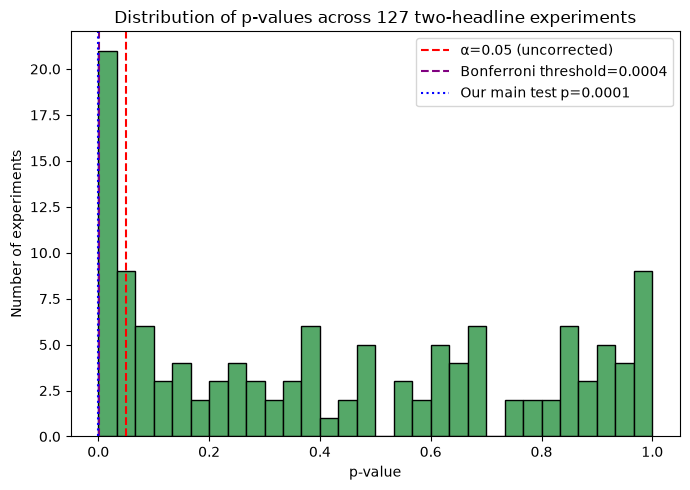

In [9]:
# 다중검정: p값 분포 히스토그램
plt.figure(figsize=(7,5))
plt.hist(pvalues, bins=30, color='#55A868', edgecolor='black')
plt.axvline(0.05, color='red', linestyle='--', label='α=0.05 (uncorrected)')
plt.axvline(bonf_threshold, color='purple', linestyle='--', label=f'Bonferroni threshold={bonf_threshold:.4f}')
plt.axvline(main_p, color='blue', linestyle=':', label=f'Our main test p={main_p}')
plt.xlabel('p-value')
plt.ylabel('Number of experiments')
plt.title('Distribution of p-values across 127 two-headline experiments')
plt.legend()
plt.tight_layout()
plt.savefig('pvalue_distribution.png', dpi=150)
plt.show()